# Install and import libraries

In [1]:
!pip install h5py tensorflow scikit-learn matplotlib pandas numpy openpyxl

You should consider upgrading via the 'C:\Users\aks36\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [2]:
import os
import h5py
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc
)

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Set configuration

In [3]:
SEED = 42
IMG_SIZE = 96
BATCH_SIZE = 32
EPOCHS = 10

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

BASE_DIR = r"D:\Fwd 2627KS0011\ML_Project"

FIGURES_DIR = r"D:\Fwd 2627KS0011\ML_Project\figures"
MODELS_DIR = r"D:\Fwd 2627KS0011\ML_Project\models"

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# Add dataset paths

In [7]:
import os

BASE_DIR = r"D:\Fwd 2627KS0011\ML_Project\pcam_dataset"  # agar pcam folder directly yahi hai

TRAIN_X_PATH = os.path.join(BASE_DIR, "pcam", "training_split.h5")
VALID_X_PATH = os.path.join(BASE_DIR, "pcam", "validation_split.h5")
TEST_X_PATH = os.path.join(BASE_DIR, "pcam", "test_split.h5")

TRAIN_Y_PATH = os.path.join(BASE_DIR, "Labels", "Labels", "camelyonpatch_level_2_split_train_y.h5")
VALID_Y_PATH = os.path.join(BASE_DIR, "Labels", "Labels", "camelyonpatch_level_2_split_valid_y.h5")
TEST_Y_PATH = os.path.join(BASE_DIR, "Labels", "Labels", "camelyonpatch_level_2_split_test_y.h5")

paths = [
    TRAIN_X_PATH, VALID_X_PATH, TEST_X_PATH,
    TRAIN_Y_PATH, VALID_Y_PATH, TEST_Y_PATH
]

for path in paths:
    print(path, "=>", os.path.exists(path))

D:\Fwd 2627KS0011\ML_Project\pcam_dataset\pcam\training_split.h5 => True
D:\Fwd 2627KS0011\ML_Project\pcam_dataset\pcam\validation_split.h5 => True
D:\Fwd 2627KS0011\ML_Project\pcam_dataset\pcam\test_split.h5 => True
D:\Fwd 2627KS0011\ML_Project\pcam_dataset\Labels\Labels\camelyonpatch_level_2_split_train_y.h5 => True
D:\Fwd 2627KS0011\ML_Project\pcam_dataset\Labels\Labels\camelyonpatch_level_2_split_valid_y.h5 => True
D:\Fwd 2627KS0011\ML_Project\pcam_dataset\Labels\Labels\camelyonpatch_level_2_split_test_y.h5 => True


# Inspect H5 keys and shapes

In [11]:
def inspect_h5(file_path):
    with h5py.File(file_path, "r") as f:
        print("File:", file_path)
        print("Keys:", list(f.keys()))
        key = list(f.keys())[0]
        print("Shape:", f[key].shape)
        print("Dtype:", f[key].dtype)
        print("-" * 60)

inspect_h5(TRAIN_X_PATH)
inspect_h5(TRAIN_Y_PATH)
inspect_h5(VALID_X_PATH)
inspect_h5(VALID_Y_PATH)
inspect_h5(TEST_X_PATH)
inspect_h5(TEST_Y_PATH)

File: D:\Fwd 2627KS0011\ML_Project\pcam_dataset\pcam\training_split.h5
Keys: ['x']
Shape: (262144, 96, 96, 3)
Dtype: uint8
------------------------------------------------------------
File: D:\Fwd 2627KS0011\ML_Project\pcam_dataset\Labels\Labels\camelyonpatch_level_2_split_train_y.h5
Keys: ['y']
Shape: (262144, 1, 1, 1)
Dtype: uint8
------------------------------------------------------------
File: D:\Fwd 2627KS0011\ML_Project\pcam_dataset\pcam\validation_split.h5
Keys: ['x']
Shape: (32768, 96, 96, 3)
Dtype: uint8
------------------------------------------------------------
File: D:\Fwd 2627KS0011\ML_Project\pcam_dataset\Labels\Labels\camelyonpatch_level_2_split_valid_y.h5
Keys: ['y']
Shape: (32768, 1, 1, 1)
Dtype: uint8
------------------------------------------------------------
File: D:\Fwd 2627KS0011\ML_Project\pcam_dataset\pcam\test_split.h5
Keys: ['x']
Shape: (32768, 96, 96, 3)
Dtype: uint8
------------------------------------------------------------
File: D:\Fwd 2627KS0011\ML_Pr

# Create helper functions to load H5 data safely

In [12]:
def get_h5_key(file_path):
    with h5py.File(file_path, "r") as f:
        return list(f.keys())[0]

TRAIN_X_KEY = get_h5_key(TRAIN_X_PATH)
VALID_X_KEY = get_h5_key(VALID_X_PATH)
TEST_X_KEY = get_h5_key(TEST_X_PATH)

TRAIN_Y_KEY = get_h5_key(TRAIN_Y_PATH)
VALID_Y_KEY = get_h5_key(VALID_Y_PATH)
TEST_Y_KEY = get_h5_key(TEST_Y_PATH)

print(TRAIN_X_KEY, TRAIN_Y_KEY)

x y


# Load labels only for distribution

In [13]:
def load_labels(label_path, label_key):
    with h5py.File(label_path, "r") as f:
        labels = np.array(f[label_key])
    labels = np.squeeze(labels).astype("int32")
    return labels

y_train = load_labels(TRAIN_Y_PATH, TRAIN_Y_KEY)
y_valid = load_labels(VALID_Y_PATH, VALID_Y_KEY)
y_test = load_labels(TEST_Y_PATH, TEST_Y_KEY)

print("Train labels:", y_train.shape)
print("Validation labels:", y_valid.shape)
print("Test labels:", y_test.shape)

print("Train class distribution:", np.bincount(y_train))
print("Validation class distribution:", np.bincount(y_valid))
print("Test class distribution:", np.bincount(y_test))

Train labels: (262144,)
Validation labels: (32768,)
Test labels: (32768,)
Train class distribution: [131072 131072]
Validation class distribution: [16399 16369]
Test class distribution: [16391 16377]


# Plot class distribution

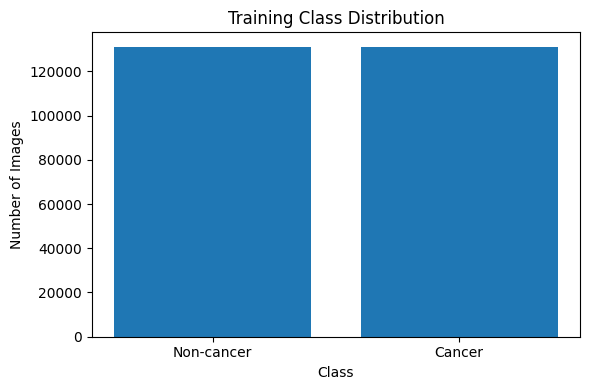

In [14]:
class_counts = np.bincount(y_train)

plt.figure(figsize=(6, 4))
plt.bar(["Non-cancer", "Cancer"], class_counts)
plt.title("Training Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "class_distribution.png"), dpi=300)
plt.show()

# Show sample images

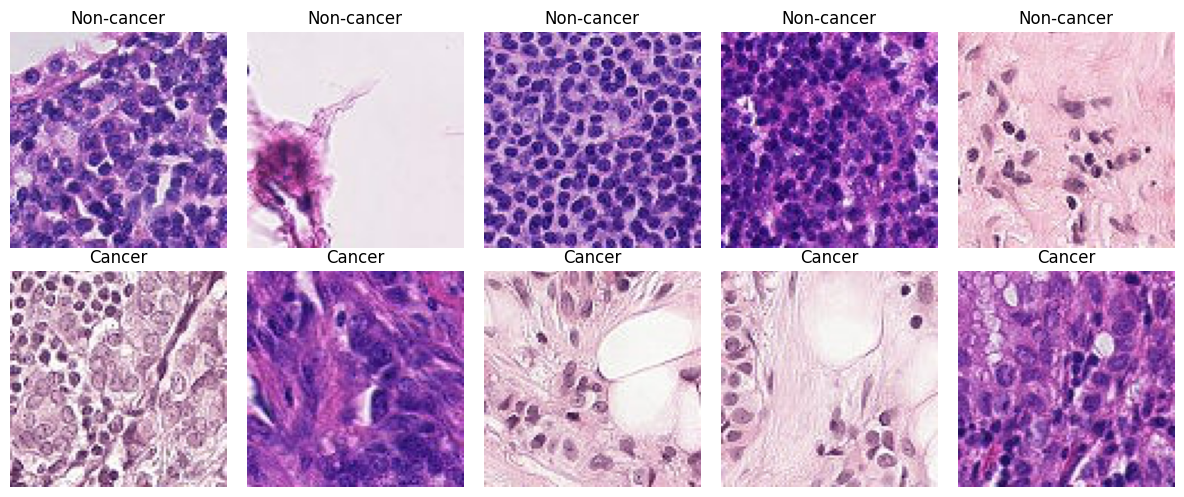

In [15]:
def load_single_image(image_path, image_key, index):
    with h5py.File(image_path, "r") as f:
        img = np.array(f[image_key][index])
    return img

non_cancer_indices = np.where(y_train == 0)[0][:5]
cancer_indices = np.where(y_train == 1)[0][:5]
sample_indices = np.concatenate([non_cancer_indices, cancer_indices])

plt.figure(figsize=(12, 5))

for i, idx in enumerate(sample_indices):
    img = load_single_image(TRAIN_X_PATH, TRAIN_X_KEY, idx)
    label = y_train[idx]
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title("Cancer" if label == 1 else "Non-cancer")
    plt.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "sample_images.png"), dpi=300)
plt.show()

# Data Pipeline

## Create H5 generator

In [16]:
def h5_data_generator(image_path, image_key, labels):
    with h5py.File(image_path, "r") as f:
        images = f[image_key]
        for i in range(len(labels)):
            image = images[i].astype("float32")
            label = labels[i].astype("float32")
            yield image, label

# Create TensorFlow datasets

In [17]:
def create_tf_dataset(image_path, image_key, labels, batch_size=32, shuffle=False):
    output_signature = (
        tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.float32)
    )

    dataset = tf.data.Dataset.from_generator(
        lambda: h5_data_generator(image_path, image_key, labels),
        output_signature=output_signature
    )

    if shuffle:
        dataset = dataset.shuffle(buffer_size=2048, seed=SEED)

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

train_ds = create_tf_dataset(TRAIN_X_PATH, TRAIN_X_KEY, y_train, BATCH_SIZE, shuffle=True)
valid_ds = create_tf_dataset(VALID_X_PATH, VALID_X_KEY, y_valid, BATCH_SIZE, shuffle=False)
test_ds = create_tf_dataset(TEST_X_PATH, TEST_X_KEY, y_test, BATCH_SIZE, shuffle=False)

# Add augmentation layer

In [18]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.10),
], name="data_augmentation")

# Custom CNN Model

In [19]:
custom_cnn = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Rescaling(1./255),
    data_augmentation,

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

custom_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

custom_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 454,465 (1.73 MB)

 Trainable params: 454,465 (1.73 MB)

 Non-trainable params: 0 (0.00 B)

# Train custom CNN

In [20]:
custom_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2
    ),
    ModelCheckpoint(
        os.path.join(MODELS_DIR, "custom_cnn_model.keras"),
        monitor="val_loss",
        save_best_only=True
    )
]

history_cnn = custom_cnn.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS,
    callbacks=custom_callbacks
)

Epoch 1/10
   8192/Unknown 754s 92ms/step - accuracy: 0.7837 - auc: 0.8605 - loss: 0.4605 - precision: 0.7787 - recall: 0.7914

c:\Users\aks36\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


8192/8192 ━━━━━━━━━━━━━━━━━━━━ 788s 96ms/step - accuracy: 0.8201 - auc: 0.8998 - loss: 0.4011 - precision: 0.8117 - recall: 0.8337 - val_accuracy: 0.7161 - val_auc: 0.8949 - val_loss: 0.6779 - val_precision: 0.9499 - val_recall: 0.4556 - learning_rate: 0.0010
Epoch 2/10
8192/8192 ━━━━━━━━━━━━━━━━━━━━ 871s 106ms/step - accuracy: 0.8735 - auc: 0.9439 - loss: 0.3034 - precision: 0.8722 - recall: 0.8751 - val_accuracy: 0.8050 - val_auc: 0.9127 - val_loss: 0.4939 - val_precision: 0.9195 - val_recall: 0.6681 - learning_rate: 0.0010
Epoch 3/10
8192/8192 ━━━━━━━━━━━━━━━━━━━━ 881s 107ms/step - accuracy: 0.8932 - auc: 0.9578 - loss: 0.2628 - precision: 0.8947 - recall: 0.8914 - val_accuracy: 0.7518 - val_auc: 0.9099 - val_loss: 0.6161 - val_precision: 0.9489 - val_recall: 0.5318 - learning_rate: 0.0010
Epoch 4/10
8192/8192 ━━━━━━━━━━━━━━━━━━━━ 935s 114ms/step - accuracy: 0.9056 - auc: 0.9656 - loss: 0.2364 - precision: 0.9096 - recall: 0.9007 - val_accuracy: 0.8274 - val_auc: 0.9316 - val_loss: 

# Plot custom CNN accuracy and loss curves

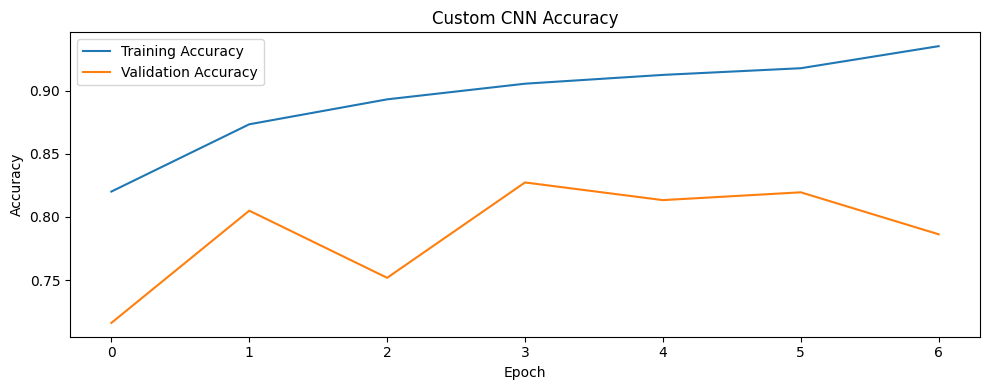

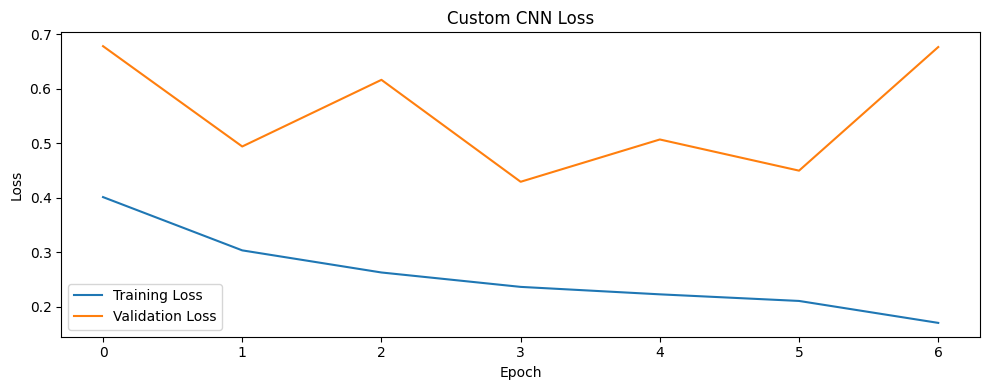

In [21]:
def plot_training_curves(history, model_name, save_name):
    plt.figure(figsize=(10, 4))

    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{model_name} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, f"{save_name}_accuracy.png"), dpi=300)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, f"{save_name}_loss.png"), dpi=300)
    plt.show()

plot_training_curves(history_cnn, "Custom CNN", "custom_cnn")

# Evaluate custom CNN

In [22]:
cnn_test_results = custom_cnn.evaluate(test_ds)
print("Custom CNN Test Results:", cnn_test_results)

1024/1024 ━━━━━━━━━━━━━━━━━━━━ 27s 26ms/step - accuracy: 0.7672 - auc: 0.9029 - loss: 0.6040 - precision: 0.9358 - recall: 0.5735
Custom CNN Test Results: [0.6039819121360779, 0.7672119140625, 0.9358373880386353, 0.5735482573509216, 0.9029188752174377]


# Predictions for custom CNN

In [23]:
y_prob_cnn = custom_cnn.predict(test_ds).ravel()
y_pred_cnn = (y_prob_cnn >= 0.5).astype("int32")

print(classification_report(
    y_test,
    y_pred_cnn,
    target_names=["Non-cancer", "Cancer"]
))

1024/1024 ━━━━━━━━━━━━━━━━━━━━ 26s 25ms/step
              precision    recall  f1-score   support

  Non-cancer       0.69      0.96      0.81     16391
      Cancer       0.94      0.57      0.71     16377

    accuracy                           0.77     32768
   macro avg       0.81      0.77      0.76     32768
weighted avg       0.81      0.77      0.76     32768



# Custom CNN confusion matrix

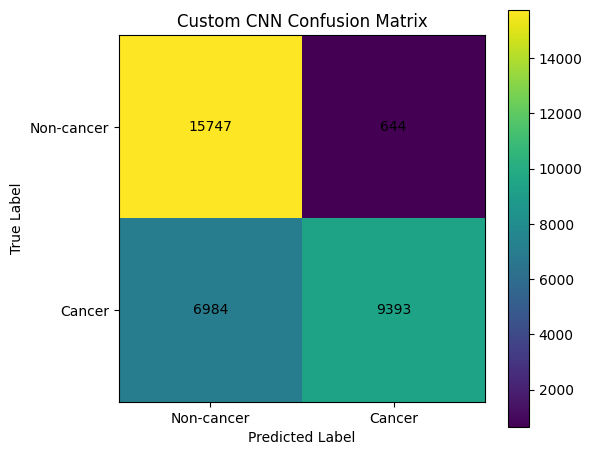

In [24]:
def plot_confusion_matrix(y_true, y_pred, title, save_name):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks([0, 1], ["Non-cancer", "Cancer"])
    plt.yticks([0, 1], ["Non-cancer", "Cancer"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.colorbar()
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, save_name), dpi=300)
    plt.show()

    return cm

cm_cnn = plot_confusion_matrix(
    y_test,
    y_pred_cnn,
    "Custom CNN Confusion Matrix",
    "custom_cnn_confusion_matrix.png"
)

# Build MobileNetV2 model

In [25]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

mobilenet_model = models.Model(inputs, outputs)

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Train MobileNetV2

In [26]:
mobilenet_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2
    ),
    ModelCheckpoint(
        os.path.join(MODELS_DIR, "mobilenetv2_model.keras"),
        monitor="val_loss",
        save_best_only=True
    )
]

history_mobilenet = mobilenet_model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS,
    callbacks=mobilenet_callbacks
)

Epoch 1/10
   8192/Unknown 592s 72ms/step - accuracy: 0.8135 - auc: 0.8940 - loss: 0.4078 - precision: 0.8168 - recall: 0.8094

c:\Users\aks36\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


8192/8192 ━━━━━━━━━━━━━━━━━━━━ 738s 90ms/step - accuracy: 0.8359 - auc: 0.9166 - loss: 0.3661 - precision: 0.8407 - recall: 0.8289 - val_accuracy: 0.8176 - val_auc: 0.9042 - val_loss: 0.3970 - val_precision: 0.8174 - val_recall: 0.8176 - learning_rate: 1.0000e-04
Epoch 2/10
8192/8192 ━━━━━━━━━━━━━━━━━━━━ 763s 93ms/step - accuracy: 0.8590 - auc: 0.9362 - loss: 0.3220 - precision: 0.8649 - recall: 0.8510 - val_accuracy: 0.8195 - val_auc: 0.9081 - val_loss: 0.3990 - val_precision: 0.8563 - val_recall: 0.7675 - learning_rate: 1.0000e-04
Epoch 3/10
8192/8192 ━━━━━━━━━━━━━━━━━━━━ 652s 80ms/step - accuracy: 0.8667 - auc: 0.9416 - loss: 0.3086 - precision: 0.8728 - recall: 0.8585 - val_accuracy: 0.8219 - val_auc: 0.9082 - val_loss: 0.4114 - val_precision: 0.8646 - val_recall: 0.7630 - learning_rate: 1.0000e-04
Epoch 4/10
8192/8192 ━━━━━━━━━━━━━━━━━━━━ 623s 76ms/step - accuracy: 0.8733 - auc: 0.9463 - loss: 0.2963 - precision: 0.8787 - recall: 0.8662 - val_accuracy: 0.8243 - val_auc: 0.9106 - v

# Plot MobileNetV2 curves

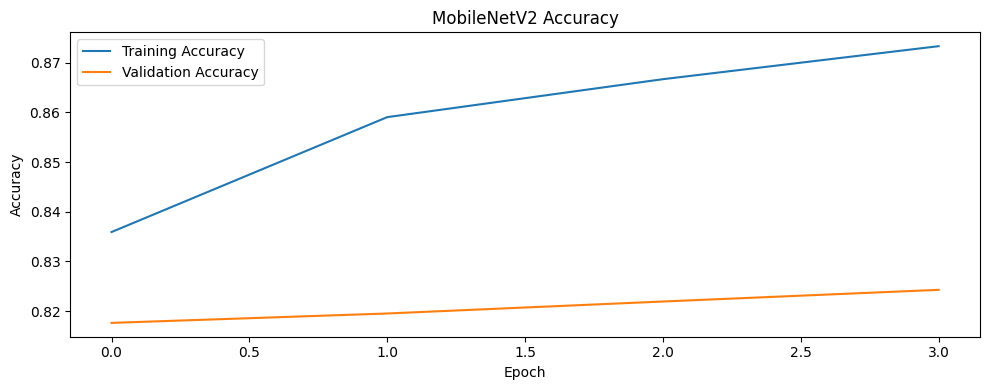

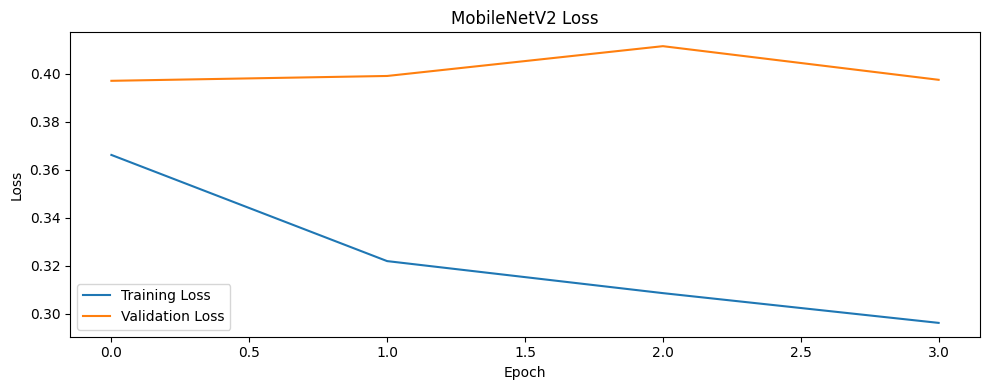

In [27]:
plot_training_curves(history_mobilenet, "MobileNetV2", "mobilenetv2")

# Evaluate MobileNetV2

In [28]:
mobilenet_test_results = mobilenet_model.evaluate(test_ds)
print("MobileNetV2 Test Results:", mobilenet_test_results)

1024/1024 ━━━━━━━━━━━━━━━━━━━━ 56s 55ms/step - accuracy: 0.7888 - auc: 0.8748 - loss: 0.4661 - precision: 0.8226 - recall: 0.7363
MobileNetV2 Test Results: [0.46612057089805603, 0.788848876953125, 0.8226224780082703, 0.7362765073776245, 0.8748363256454468]


# MobileNetV2 predictions and report

In [29]:
y_prob_mobilenet = mobilenet_model.predict(test_ds).ravel()
y_pred_mobilenet = (y_prob_mobilenet >= 0.5).astype("int32")

print(classification_report(
    y_test,
    y_pred_mobilenet,
    target_names=["Non-cancer", "Cancer"]
))

1024/1024 ━━━━━━━━━━━━━━━━━━━━ 57s 55ms/step
              precision    recall  f1-score   support

  Non-cancer       0.76      0.84      0.80     16391
      Cancer       0.82      0.74      0.78     16377

    accuracy                           0.79     32768
   macro avg       0.79      0.79      0.79     32768
weighted avg       0.79      0.79      0.79     32768



# MobileNetV2 confusion matrix

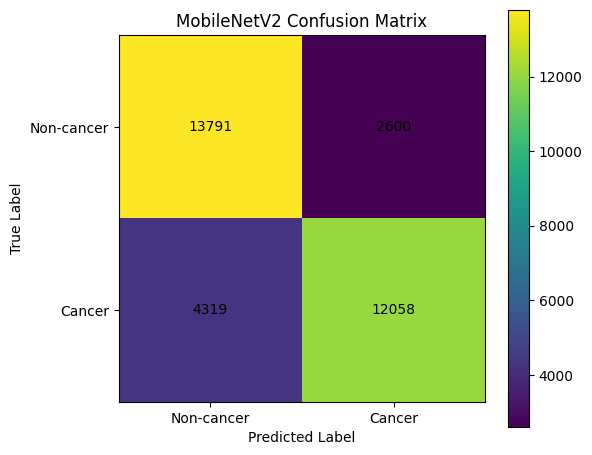

In [30]:
cm_mobilenet = plot_confusion_matrix(
    y_test,
    y_pred_mobilenet,
    "MobileNetV2 Confusion Matrix",
    "mobilenetv2_confusion_matrix.png"
)

# ROC-AUC comparison

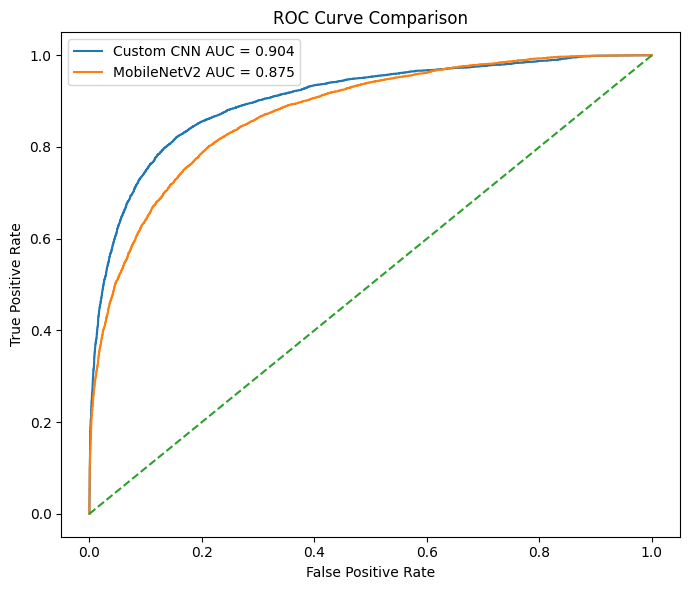

In [31]:
fpr_cnn, tpr_cnn, _ = roc_curve(y_test, y_prob_cnn)
auc_cnn = auc(fpr_cnn, tpr_cnn)

fpr_mobilenet, tpr_mobilenet, _ = roc_curve(y_test, y_prob_mobilenet)
auc_mobilenet = auc(fpr_mobilenet, tpr_mobilenet)

plt.figure(figsize=(7, 6))
plt.plot(fpr_cnn, tpr_cnn, label=f"Custom CNN AUC = {auc_cnn:.3f}")
plt.plot(fpr_mobilenet, tpr_mobilenet, label=f"MobileNetV2 AUC = {auc_mobilenet:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "roc_curve_comparison.png"), dpi=300)
plt.show()

# Create comparison table

In [32]:
comparison_df = pd.DataFrame({
    "Model": ["Custom CNN", "MobileNetV2"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_cnn),
        accuracy_score(y_test, y_pred_mobilenet)
    ],
    "Precision": [
        precision_score(y_test, y_pred_cnn),
        precision_score(y_test, y_pred_mobilenet)
    ],
    "Recall": [
        recall_score(y_test, y_pred_cnn),
        recall_score(y_test, y_pred_mobilenet)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_cnn),
        f1_score(y_test, y_pred_mobilenet)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_cnn),
        roc_auc_score(y_test, y_prob_mobilenet)
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Custom CNN,0.767212,0.935837,0.573548,0.711214,0.903745
1,MobileNetV2,0.788849,0.822622,0.736276,0.777058,0.874885


In [33]:
comparison_df.to_csv(os.path.join(FIGURES_DIR, "model_comparison_table.csv"), index=False)

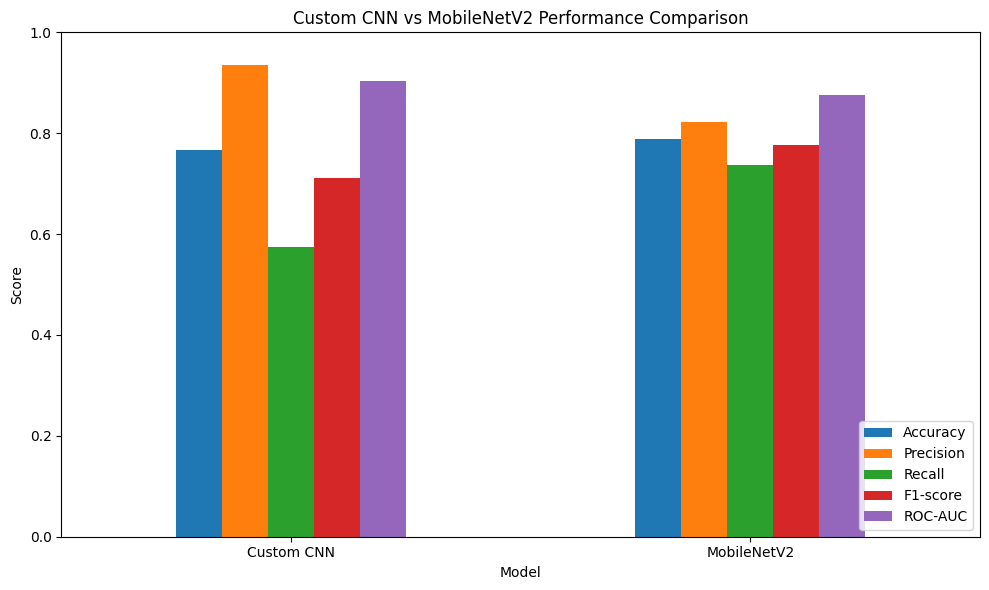

In [34]:
comparison_df.set_index("Model").plot(kind="bar", figsize=(10, 6))
plt.title("Custom CNN vs MobileNetV2 Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "model_comparison_chart.png"), dpi=300)
plt.show()

# Display sample predictions

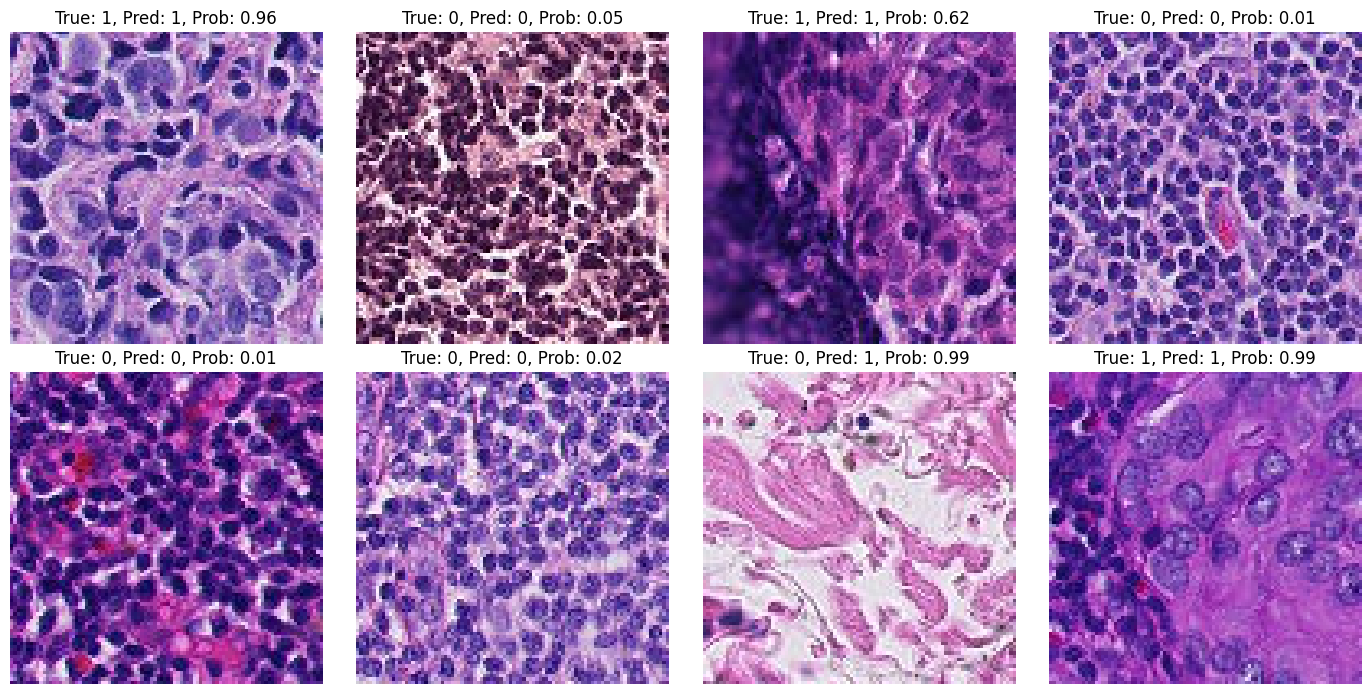

In [35]:
sample_indices = np.random.choice(len(y_test), size=8, replace=False)

plt.figure(figsize=(14, 7))

for i, idx in enumerate(sample_indices):
    img = load_single_image(TEST_X_PATH, TEST_X_KEY, idx)
    img_batch = np.expand_dims(img.astype("float32"), axis=0)

    prob = mobilenet_model.predict(img_batch, verbose=0)[0][0]
    pred = 1 if prob >= 0.5 else 0
    true = y_test[idx]

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(f"True: {true}, Pred: {pred}, Prob: {prob:.2f}")
    plt.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "sample_predictions.png"), dpi=300)
plt.show()

# Save models

In [36]:
custom_cnn.save(os.path.join(MODELS_DIR, "custom_cnn_final.keras"))
mobilenet_model.save(os.path.join(MODELS_DIR, "mobilenetv2_final.keras"))